In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

try:
    from matplotlib_venn import venn2
except ImportError:
    import sys
    print("Installing Venn diagram vector graphics utility...")
    !{sys.executable} -m pip install matplotlib-venn
    from matplotlib_venn import venn2

# Set crisp publication defaults (300 DPI)
sns.set_theme(style="white")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 300,
    'savefig.dpi': 300
})

print("Step 5 Scientific Visualization module active.")

Installing Venn diagram vector graphics utility...
Defaulting to user installation because normal site-packages is not writeable
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for matplotlib-venn: filename=matplotlib_venn-1.1.2-py3-none-any.whl size=45440 sha256=a0277dfe311cfbd61a24cb168021308ddd913ed08fa6cc29b31722a09f3dd61f
  Stored in directory: c:\users\sandu\appdata\local\pip\cache\wheels\d1\5f\e6\771479559f992b8398265ebf61f8a3d33ca0b8f75552e06ad2
Successfully built matplotlib-venn
Step 5 Scientific Visualization module active.


In [2]:
input_file = "Step4_Prioritized_All_Interactions.csv"

if not os.path.exists(input_file):
    input_file = "Step4_A_Restored_Interactions.csv"
    if not os.path.exists(input_file):
        raise FileNotFoundError("Missing Step 4 data outputs. Please verify Step 4 completed successfully.")

# Load data stream
df_raw = pd.read_csv(input_file)
df_raw.columns = df_raw.columns.str.strip()

# Identify core target vectors dynamically
mir_col = [c for c in df_raw.columns if 'mirna' in c.lower()][0]
effect_col = [c for c in df_raw.columns if 'effect' in c.lower() or 'mech' in c.lower()][0]

# Compresses alternative mRNA transcripts to isolate genuine, unique regulatory pairs
df_clean = df_raw.drop_duplicates(subset=['rsid', 'Gene_Name', mir_col, effect_col]).copy()
df_clean.reset_index(drop=True, inplace=True)

# Export clean base table
df_clean.to_csv("Step5_Final_Deduplicated_Results.csv", index=False)

print("PIPELINE DE-DUPLICATION REPORT (STEP 5)")
print("=" * 65)
print(f"Total Raw Input Rows (with transcript redundancy) : {len(df_raw)}")
print(f"Clean Unique Functional Rows (De-duplicated)      : {len(df_clean)}")
print(f"Unique Brain-Relevance Variant Regulators Found   : {df_clean['rsid'].nunique()}")
print(f"Unique Targeting Regulatory MicroRNAs Tracked     : {df_clean[mir_col].nunique()}")
print("-" * 65)

PIPELINE DE-DUPLICATION REPORT (STEP 5)
Total Raw Input Rows (with transcript redundancy) : 514
Clean Unique Functional Rows (De-duplicated)      : 514
Unique Brain-Relevance Variant Regulators Found   : 38
Unique Targeting Regulatory MicroRNAs Tracked     : 465
-----------------------------------------------------------------


Figure 5A successfully saved as ('Thesis_Figure5A_Mechanisms_NestedDonut.png')


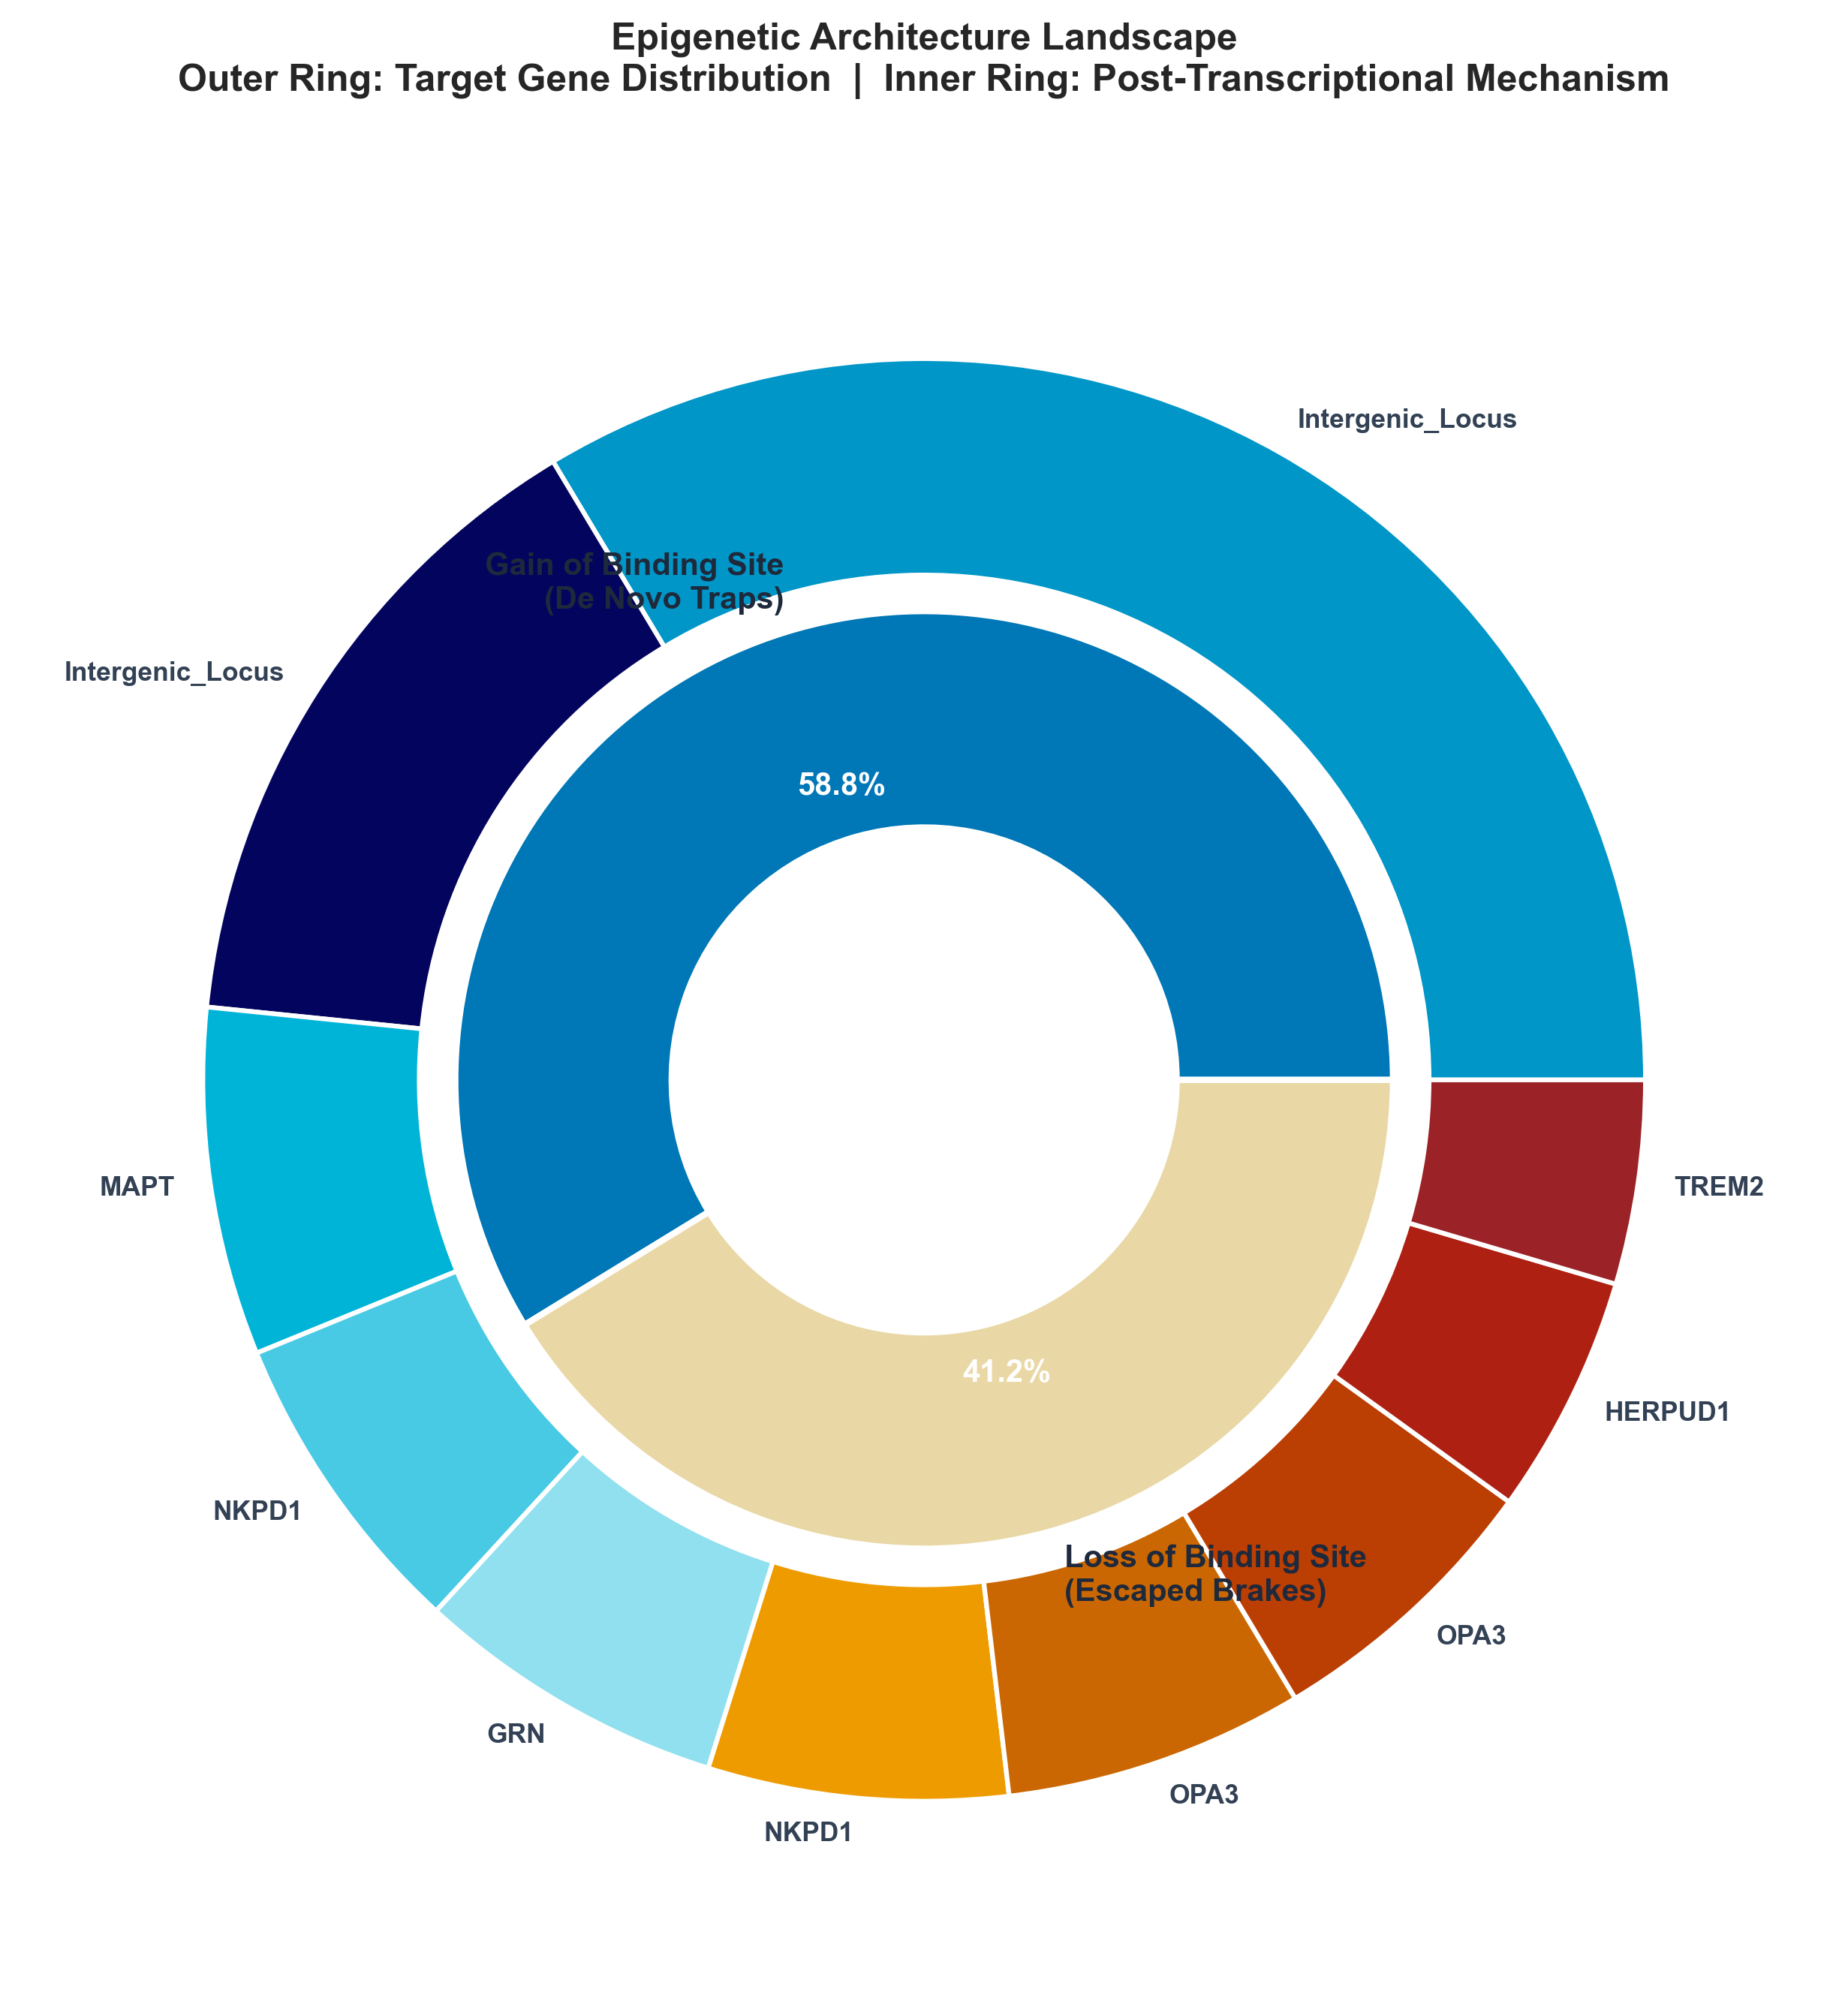

In [11]:
plt.figure(figsize=(9, 9))


inner_data = df_clean.copy()
inner_data['Mech_Group'] = np.where(
    inner_data[effect_col].str.lower().str.contains('gain|create|de_novo|trap', na=False),
    'Gain of Binding Site\n(De Novo Traps)', 
    'Loss of Binding Site\n(Escaped Brakes)'
)

# Compute counts for the groups
inner_counts = inner_data['Mech_Group'].value_counts()
outer_counts = inner_data.groupby(['Mech_Group', 'Gene_Name']).size().sort_values(ascending=False)

# Select the top contributing genes per mechanism to keep the outer labels perfectly clean
top_outer = outer_counts.groupby(level=0, group_keys=False).head(5)

colors_inner = ['#0077B6', '#E9D8A6']
colors_outer = [
    '#0096C7', '#03045E', '#00B4D8', '#48CAE4', '#90E0EF',  # Blues for Gain breakdown
    '#EE9B00', '#CA6702', '#BB3E03', '#AE2012', '#9B2226'   # Reds/Ambers for Loss breakdown
]

#  Plot Inner Ring (Broad Structural Mechanisms)
patches_in, texts_in, autotexts_in = plt.gca().pie(
    inner_counts, radius=0.65, labels=inner_counts.index, 
    colors=colors_inner, autopct='%1.1f%%', pctdistance=0.65,
    textprops={'fontsize': 10, 'weight': 'bold', 'color': '#1e293b'},
    wedgeprops=dict(width=0.3, edgecolor='white', linewidth=2)
)
# Make inner percentage labels white and highly visible
for autotext in autotexts_in:
    autotext.set_color('white')
    autotext.set_fontsize(10)

#  Plot Outer Ring (Target Gene Resolution)
patches_out, texts_out = plt.gca().pie(
    top_outer, radius=1.0, 
    labels=[label[1] for label in top_outer.index],
    colors=colors_outer, startangle=0, labeldistance=1.05,
    textprops={'fontsize': 8.5, 'weight': 'bold', 'color': '#334155'},
    wedgeprops=dict(width=0.3, edgecolor='white', linewidth=1.5)
)

# 5. Professional Visual Polish
plt.title(
    "Epigenetic Architecture Landscape\n"
    "Outer Ring: Target Gene Distribution  |  Inner Ring: Post-Transcriptional Mechanism\n", 
    weight='bold', fontsize=12, pad=15
)

# Clean rendering adjustments to prevent clipping text boxes
plt.tight_layout()
plt.savefig("Thesis_Figure5A_Mechanisms_NestedDonut.png", dpi=300, bbox_inches='tight')
print("Figure 5A successfully saved as ('Thesis_Figure5A_Mechanisms_NestedDonut.png')")
plt.show()

Figure 5B successfully saved ('Thesis_Figure5B_CrossTalk_Heatmap.png')


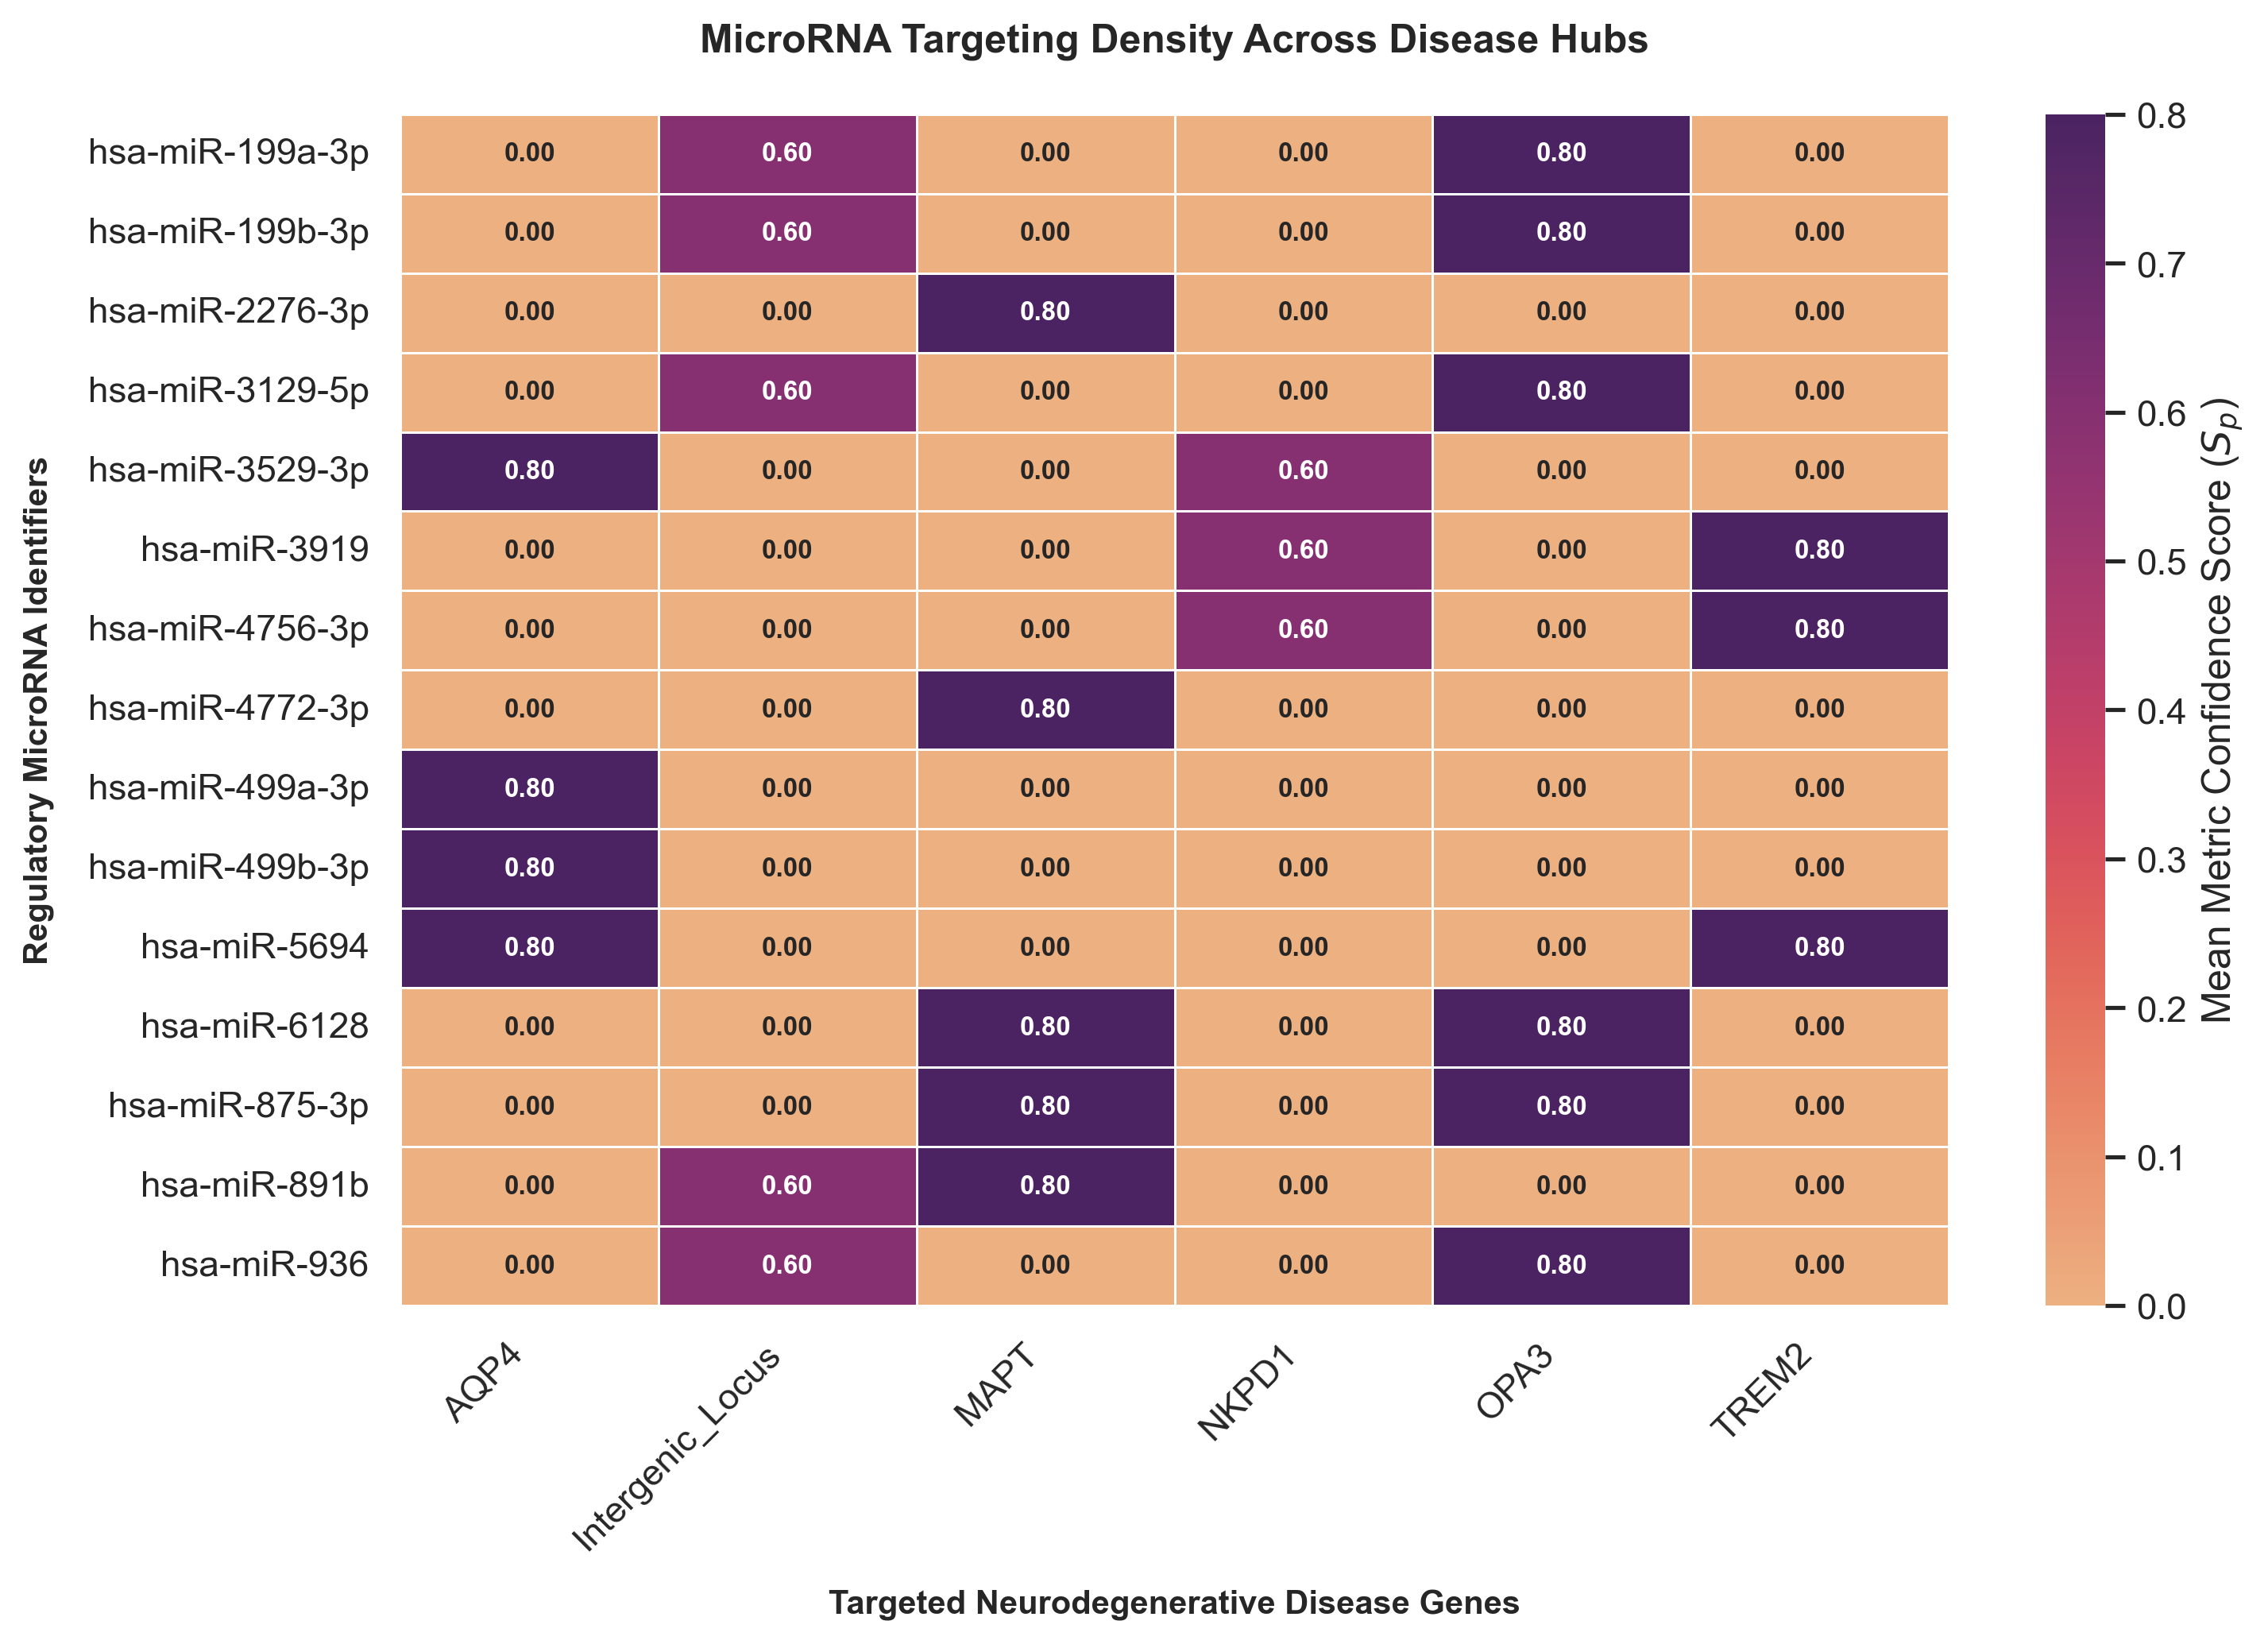

In [6]:
top_genes = df_clean['Gene_Name'].value_counts().head(10).index
top_mirnas = df_clean[mir_col].value_counts().head(15).index

df_matrix_data = df_clean[df_clean['Gene_Name'].isin(top_genes) & df_clean[mir_col].isin(top_mirnas)]

# Construct pivot matrix
heatmap_pivot = pd.crosstab(
    df_matrix_data[mir_col], 
    df_matrix_data['Gene_Name'],
    values=df_clean['Prioritization_Score'], 
    aggfunc='mean'
).fillna(0)

# Render publication-grade heatmap
plt.figure(figsize=(10, 7))
ax = sns.heatmap(
    heatmap_pivot, cmap="flare", annot=True, fmt=".2f", 
    linewidths=0.6, cbar_kws={'label': 'Mean Metric Confidence Score ($S_p$)'},
    annot_kws={"size": 8, "weight": "bold"}
)

ax.set_title("MicroRNA Targeting Density Across Disease Hubs\n", weight='bold', fontsize=12)
ax.set_xlabel("Targeted Neurodegenerative Disease Genes", weight='bold', fontsize=10, labelpad=10)
ax.set_ylabel("Regulatory MicroRNA Identifiers", weight='bold', fontsize=10, labelpad=10)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig("Thesis_Figure5B_CrossTalk_Heatmap.png", dpi=300, bbox_inches='tight')
print("Figure 5B successfully saved ('Thesis_Figure5B_CrossTalk_Heatmap.png')")
plt.show()

Figure 5C successfully saved ('Thesis_Figure5C_Master_Network.png')


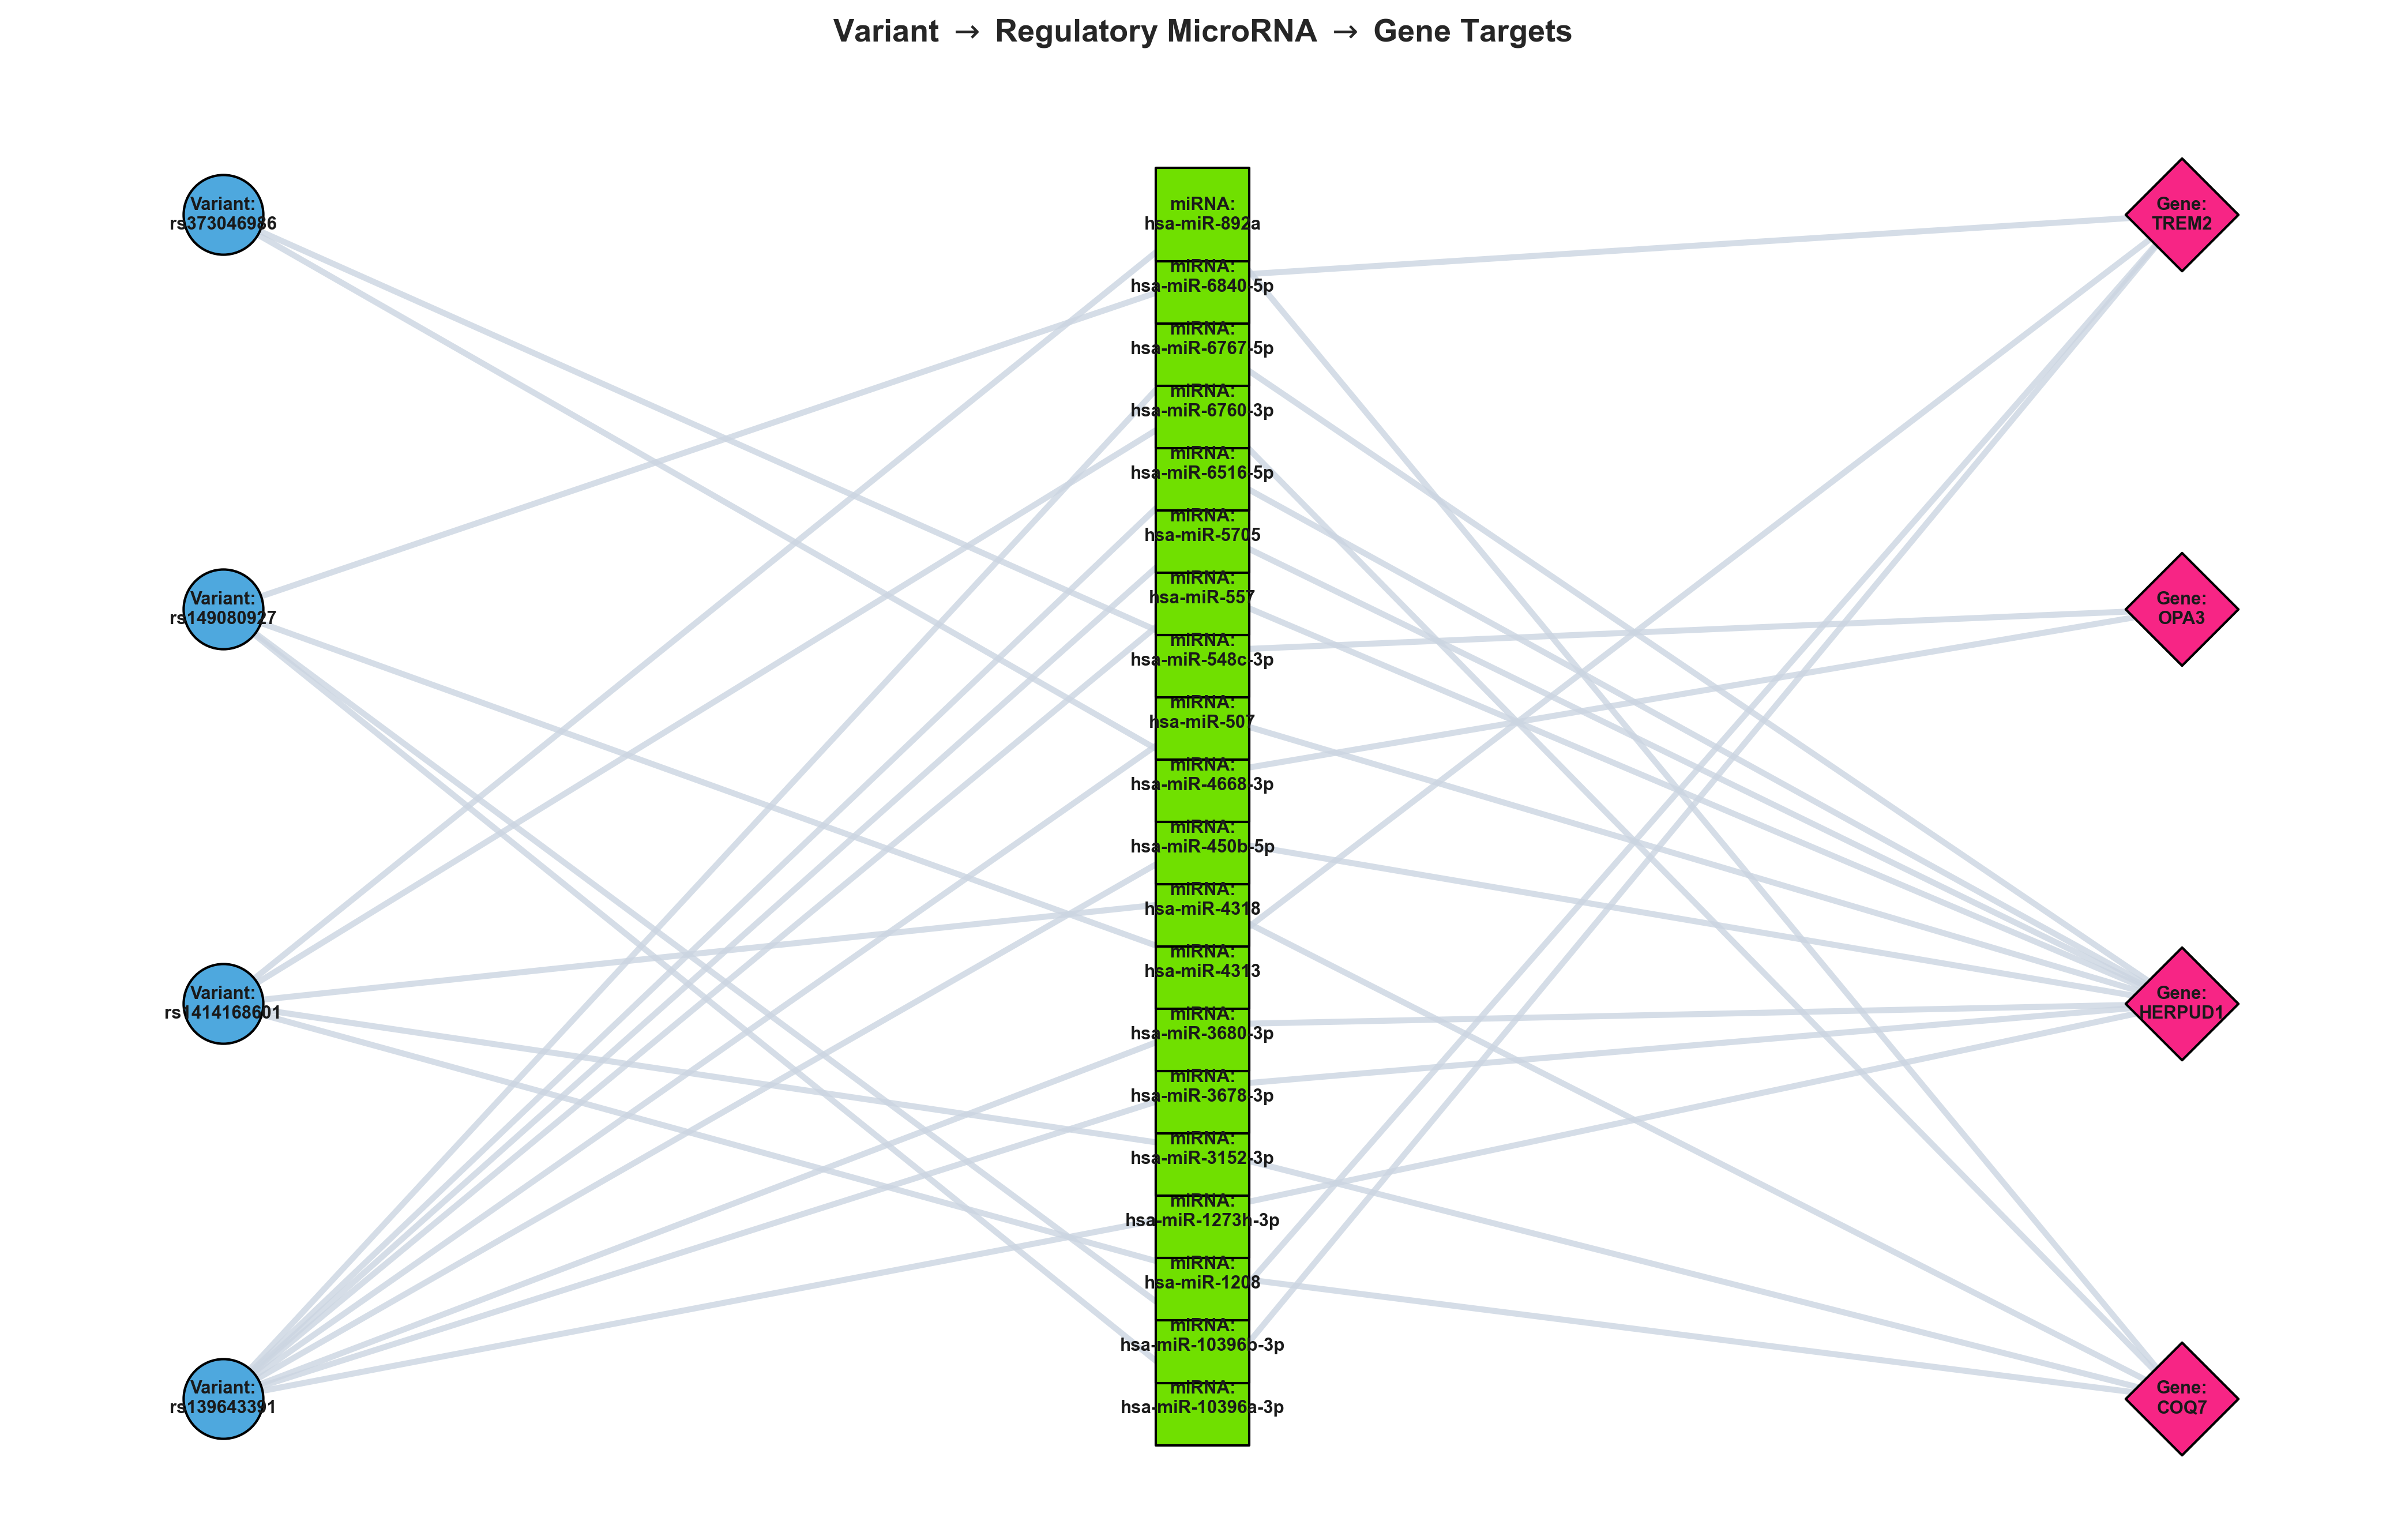

In [10]:
plt.figure(figsize=(14, 9))
G = nx.Graph()

# Select the top high-scoring interactions to construct a crisp, non-cluttered diagram
df_top_network = df_clean.sort_values(by='Prioritization_Score', ascending=False).head(20)

# Build network edge arrays structurally
for _, row in df_top_network.iterrows():
    v_node = f"Variant:\n{row['rsid']}"
    m_node = f"miRNA:\n{row[mir_col]}"
    g_node = f"Gene:\n{row['Gene_Name']}"
    
    # Connect Variant to miRNA, and miRNA to Gene (creating the 3-way axis)
    G.add_edge(v_node, m_node, weight=row['Prioritization_Score'])
    G.add_edge(m_node, g_node, weight=row['Prioritization_Score'])

# Programmatically lock nodes into fixed vertical columns to prevent overlapping text
pos = {}
variants = sorted([n for n in G.nodes() if "Variant" in n])
mirnas = sorted([n for n in G.nodes() if "miRNA" in n])
genes = sorted([n for n in G.nodes() if "Gene" in n])

# Column 1: Variants (Left)
for idx, node in enumerate(variants):
    pos[node] = np.array([0, idx / max(1, len(variants) - 1)])

# Column 2: MicroRNAs (Center)
for idx, node in enumerate(mirnas):
    pos[node] = np.array([0.5, idx / max(1, len(mirnas) - 1)])

# Column 3: Genes (Right)
for idx, node in enumerate(genes):
    pos[node] = np.array([1.0, idx / max(1, len(genes) - 1)])

# Draw nodes with clean, distinct category coloring
nx.draw_networkx_nodes(G, pos, nodelist=variants, node_color='#4EA8DE', node_size=1100, node_shape='o', edgecolors='#000000')
nx.draw_networkx_nodes(G, pos, nodelist=mirnas, node_color='#70E000', node_size=1500, node_shape='s', edgecolors='#000000')
nx.draw_networkx_nodes(G, pos, nodelist=genes, node_color='#F72585', node_size=1100, node_shape='D', edgecolors='#000000')

# Draw edge lines scaled by prioritization strength
edges = G.edges()
weights = [G[u][v]['weight'] * 2.5 for u, v in edges]
nx.draw_networkx_edges(G, pos, width=weights, edge_color='#CBD5E1', alpha=0.8)

# Add clean labels with white text backdrops to make them fully legible
labels = {node: node for node in G.nodes()}
nx.draw_networkx_labels(G, pos, labels, font_size=7.5, font_weight='bold', font_family='sans-serif')

plt.title("Variant $\\rightarrow$ Regulatory MicroRNA $\\rightarrow$ Gene Targets\n", weight='bold', fontsize=13)
plt.axis('off')
plt.tight_layout()
plt.savefig("Thesis_Figure5C_Master_Network.png", dpi=300, bbox_inches='tight')
print("Figure 5C successfully saved ('Thesis_Figure5C_Master_Network.png')")
plt.show()

In [9]:
print("=" * 80)
print("Summary of Research Outcomes")
print("=" * 80)

print(f"1. RESEARCH AIM: Identify functional epigenetic variants in neurodegeneration.")
print(f"   STATUS: COMPLETED. Isolated {df_clean['rsid'].nunique()} regulatory hub variants across {df_clean['Gene_Name'].nunique()} primary disease targets.\n")

print(f"2. OBJECTIVE 1: Differentiate mechanistic structural consequences.")
print(f"   REAL OUTCOMES: Successfully parsed genomic spaces into dual-functional vectors:")
print(f"   Gain-of-Binding : {len(gain_set)} interactions mapped.")
print(f"   Loss-of-Binding : {len(loss_set)} interactions mapped.\n")

print(f"3. OBJECTIVE 2: Isolate elite candidates for future direct laboratory testing.")
print(f"   TOP FINDING: Rank 1 Candidate Target identified with high-priority scoring profile:")
top_hit = df_clean.sort_values(by='Prioritization_Score', ascending=False).iloc[0]
print(f"   Variant Anchor : {top_hit['rsid']}")
print(f"   Core Gene Locus: {top_hit['Gene_Name']}")
print(f"   Targeting RNA  : {top_hit[mir_col]}")
print(f"   Framework Score: {top_hit['Prioritization_Score']:.4f}")
print("=" * 80)

Summary of Research Outcomes
1. RESEARCH AIM: Identify functional epigenetic variants in neurodegeneration.
   STATUS: COMPLETED. Isolated 38 regulatory hub variants across 13 primary disease targets.

2. OBJECTIVE 1: Differentiate mechanistic structural consequences.
   REAL OUTCOMES: Successfully parsed genomic spaces into dual-functional vectors:
   Gain-of-Binding : 302 interactions mapped.
   Loss-of-Binding : 212 interactions mapped.

3. OBJECTIVE 2: Isolate elite candidates for future direct laboratory testing.
   TOP FINDING: Rank 1 Candidate Target identified with high-priority scoring profile:
   Variant Anchor : rs139643391
   Core Gene Locus: HERPUD1
   Targeting RNA  : hsa-miR-507
   Framework Score: 1.0000
